In [60]:
!pip install biopython networkx scipy pandas numpy matplotlib infomap scikit-learn

In [61]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt


from Bio.PDB import PDBParser
from scipy.spatial import cKDTree
from collections import Counter

In [62]:
PDB_FILES = [
    "data/raw/6B1T/6b1t-pdb-bundle1.pdb",
    "data/raw/6B1T/6b1t-pdb-bundle2.pdb"
]

In [63]:
AA_CLASS = {

    # Hidrofóbicos
    "ALA":"hydrophobic",
    "VAL":"hydrophobic",
    "ILE":"hydrophobic",
    "LEU":"hydrophobic",
    "MET":"hydrophobic",
    "PHE":"hydrophobic",
    "TRP":"hydrophobic",
    "PRO":"hydrophobic",

    # Polares
    "SER":"polar",
    "THR":"polar",
    "ASN":"polar",
    "GLN":"polar",
    "TYR":"polar",
    "CYS":"polar",

    # Positivos
    "LYS":"positive",
    "ARG":"positive",
    "HIS":"positive",

    # Negativos
    "ASP":"negative",
    "GLU":"negative",

    # Glicina
    "GLY":"special"
}

In [64]:
def biochemical_similarity(res1, res2):

    c1 = AA_CLASS.get(res1, "other")
    c2 = AA_CLASS.get(res2, "other")

    if c1 == c2:
        return 1.0

    # atração eletrostática
    if (
        (c1 == "positive" and c2 == "negative")
        or
        (c1 == "negative" and c2 == "positive")
    ):
        return 0.9

    # polar-polar
    if (
        c1 == "polar"
        and
        c2 == "polar"
    ):
        return 0.8

    # hidrofóbico-polar
    if (
        c1 == "hydrophobic"
        and
        c2 == "polar"
    ) or (
        c2 == "hydrophobic"
        and
        c1 == "polar"
    ):
        return 0.3

    return 0.5

In [65]:
def load_residues(pdb_files):
    parser = PDBParser(QUIET=True)
    residues = []
    for pdb_file in pdb_files:
        structure = parser.get_structure("6B1T", pdb_file)
        for model in structure:
            for chain in model:
                for residue in chain:
                    if residue.id[0] != " ":
                        continue
                    if "CA" not in residue:
                        continue
                    ca = residue["CA"]
                    residues.append({
                        "node_id":
                        f"{chain.id}_{residue.id[1]}",
                        "chain":
                        chain.id,
                        "resname":
                        residue.resname,
                        "resid":
                        residue.id[1],
                        "x":
                        float(ca.coord[0]),
                        "y":
                        float(ca.coord[1]),
                        "z":
                        float(ca.coord[2])
                    })
    return pd.DataFrame(residues)

In [66]:
res_df = load_residues(PDB_FILES)
print("Resíduos:", len(res_df))
res_df.head()

Resíduos: 12544


,node_id,chain,resname,resid,x,y,z
0,A_6,A,MET,6,35.067001,140.119003,314.084015
1,A_7,A,MET,7,32.890999,138.360001,316.661987
2,A_8,A,PRO,8,29.086000,138.692993,316.332001
3,A_9,A,GLN,9,28.686001,139.419006,320.045013
4,A_10,A,TRP,10,31.304001,142.171997,320.027008


In [67]:
def build_biophysical_graph(residues_df, cutoff, alpha, beta):

    G = nx.Graph()
    
    for row in residues_df.itertuples():
        G.add_node(
            row.node_id,
            chain=row.chain,
            residue=row.resname,
            resid=row.resid
        )
    
    coords = residues_df[
        ["x","y","z"]
    ].values

    node_ids = residues_df["node_id"].values
    residues = residues_df["resname"].values

    tree = cKDTree(coords)
    pairs = tree.query_pairs(r=cutoff)

    for i,j in pairs:
        distance = np.linalg.norm(coords[i]-coords[j])
        spatial_weight = np.exp(-distance/cutoff)
        bio_weight = biochemical_similarity(residues[i],residues[j])
        final_weight = (alpha*spatial_weight + beta*bio_weight)

        G.add_edge(
            node_ids[i],
            node_ids[j],
            distance=distance,
            spatial_weight=spatial_weight,
            bio_weight=bio_weight,
            weight=final_weight
        )

    return G

In [68]:
# Distância máxima para considerar uma interação (Angstroms)
cutoff=8.0

# alpha e beta definem o Peso da interação
alpha=0.2   # Distância Espacial
beta=0.8    # Similaridade Biofísica

G = build_biophysical_graph(res_df, cutoff, alpha, beta)

print("Nós:", G.number_of_nodes())
print("Arestas:", G.number_of_edges())

# Listar os nós com atributos
nodes_df = pd.DataFrame.from_dict(dict(G.nodes(data=True)), orient="index")
display(nodes_df.head())

# Listar as arestas com atributos
edges_df = pd.DataFrame([
    {"source": u, "target": v, **d}
    for u, v, d in G.edges(data=True)
])
display(edges_df.head())

Nós: 12544
Arestas: 66809


,chain,residue,resid
A_6,A,MET,6
A_7,A,MET,7
A_8,A,PRO,8
A_9,A,GLN,9
A_10,A,TRP,10


,source,target,distance,spatial_weight,bio_weight,weight
0,A_6,A_10,7.327627,0.400135,1.0,0.880027
1,A_6,A_7,3.804605,0.621527,1.0,0.924305
2,A_6,A_11,7.183429,0.407413,0.3,0.321483
3,A_6,A_16,7.136373,0.409816,0.3,0.321963
4,A_6,A_8,6.546703,0.441164,1.0,0.888233


In [69]:
degrees = [d for _,d in G.degree()]

print("Grau médio:", np.mean(degrees))
print("Grau máximo:", np.max(degrees))
print("Densidade:", nx.density(G))

Grau médio: 10.651945153061224
Grau máximo: 20
Densidade: 0.0008492342464371541


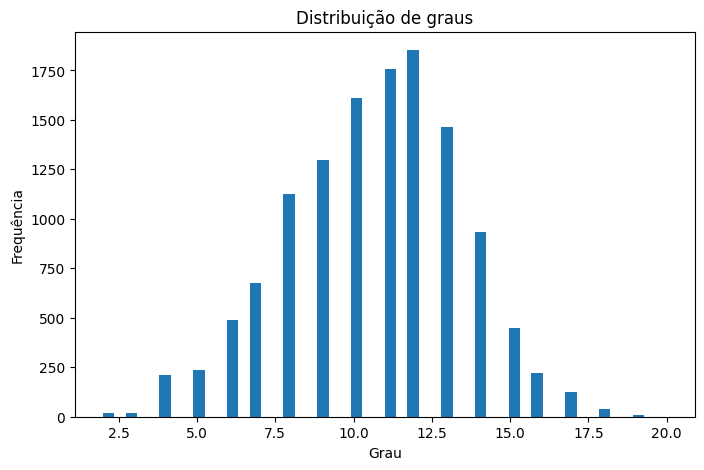

In [70]:
plt.figure(figsize=(8,5))

plt.hist(
    degrees,
    bins=50
)

plt.xlabel("Grau")
plt.ylabel("Frequência")
plt.title("Distribuição de graus")

plt.show()

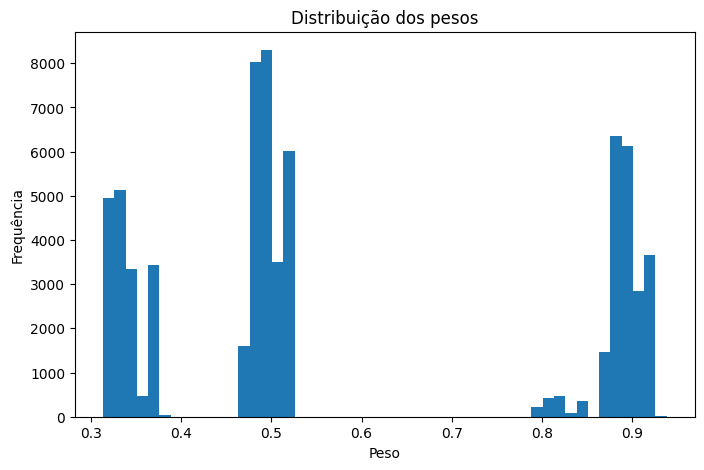

In [71]:
weights = [
    G[u][v]["weight"]
    for u,v in G.edges()
]

plt.figure(figsize=(8,5))

plt.hist(
    weights,
    bins=50
)

plt.xlabel("Peso")
plt.ylabel("Frequência")
plt.title("Distribuição dos pesos")

plt.show()

In [72]:
chain_counts = Counter(
    nx.get_node_attributes(
        G,
        "chain"
    ).values()
)

pd.DataFrame(
    chain_counts.items(),
    columns=["Chain","Residues"]
).sort_values("Chain")

,Chain,Residues
0,A,908
1,B,910
2,C,910
3,D,906
4,E,914
5,F,910
6,G,909
7,H,913
8,I,910
9,J,913


Se a modelagem estiver adequada:

A rede terá algo entre dezenas e centenas de milhares de arestas.
Os pesos apresentarão distribuição multimodal.
Os resíduos da cadeia M (Penton) deverão apresentar perfil topológico diferente dos resíduos das cadeias A-L (Hexons).
A matriz de adjacência já começará a exibir blocos estruturais, favorecendo posteriormente:
Louvain;
Infomap;
Bipartição espectral (Fiedler Vector).

In [73]:
from scipy.sparse import csgraph

A = nx.to_numpy_array(G, weight="weight")
print(A.shape)

L = csgraph.laplacian(A, normed=False)
print(L.shape)

L_norm = csgraph.laplacian(A, normed=True)
print(L_norm.shape)

(12544, 12544)
(12544, 12544)
(12544, 12544)


In [74]:
from scipy.sparse.linalg import eigsh

eigenvalues, eigenvectors = eigsh(
    L_norm,
    k=10,
    which="SM"
)

print(eigenvalues)

[-4.18447723e-16  5.36728358e-04  1.06325401e-03  1.16431238e-03
  1.46998134e-03  2.78770839e-03  3.28594519e-03  4.72895608e-03
  5.20167388e-03  5.49588895e-03]


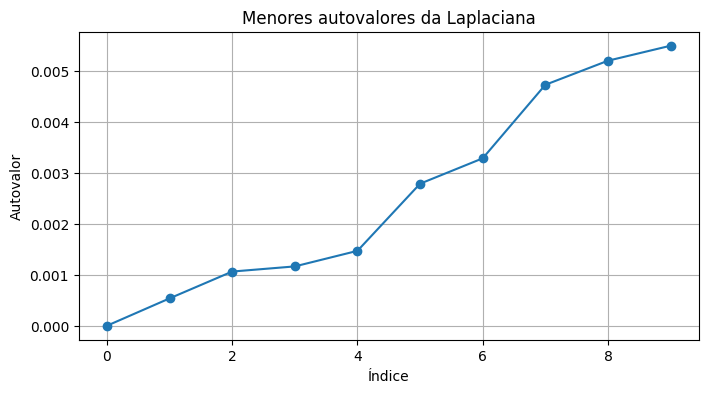

In [75]:
plt.figure(figsize=(8,4))

plt.plot(
    range(len(eigenvalues)),
    eigenvalues,
    marker="o"
)

plt.xlabel("Índice")
plt.ylabel("Autovalor")

plt.title("Menores autovalores da Laplaciana")

plt.grid()

plt.show()

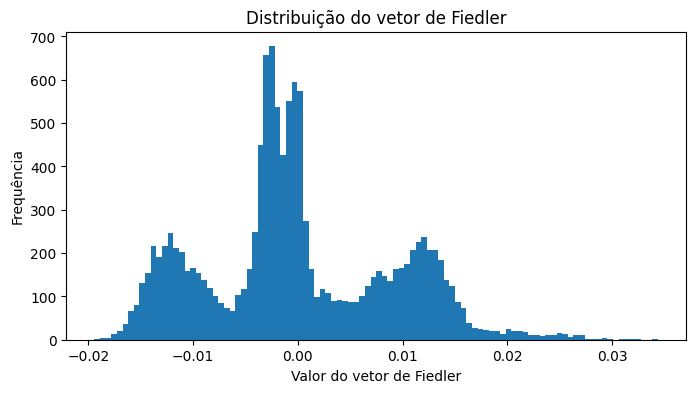

In [76]:
fiedler = eigenvectors[:,1]
plt.figure(figsize=(8,4))

plt.hist(
    fiedler,
    bins=100
)

plt.xlabel("Valor do vetor de Fiedler")
plt.ylabel("Frequência")

plt.title("Distribuição do vetor de Fiedler")

plt.show()

In [77]:
nodes = list(G.nodes())

spectral_partition = pd.DataFrame({

    "node_id": nodes,

    "spectral_group":
    (fiedler > 0).astype(int)

})

spectral_partition.head()

,node_id,spectral_group
0,A_6,1
1,A_7,1
2,A_8,1
3,A_9,1
4,A_10,1


In [78]:
spectral_partition[
    "spectral_group"
].value_counts()

spectral_group
0    7454
1    5090
Name: count, dtype: int64

In [79]:
nodes = pd.DataFrame({

    "node_id": list(G.nodes()),

    "chain": [
        G.nodes[n]["chain"]
        for n in G.nodes()
    ],

    "spectral_group":
    (fiedler > 0).astype(int)
})

pd.crosstab(
    nodes["chain"],
    nodes["spectral_group"]
)

spectral_group,0,1
chain,,
A,0,908
B,0,910
C,0,910
D,906,0
E,741,173
F,910,0
G,909,0
H,913,0
I,910,0


In [80]:
from networkx.algorithms.community import louvain_communities
from networkx.algorithms.community import modularity

louvain_comms = louvain_communities(
    G,
    weight="weight",
    seed=42,
    resolution=1.0
)

print("Comunidades:", len(louvain_comms))

Q_louvain = modularity(
    G,
    louvain_comms,
    weight="weight"
)

print("Modularidade:", Q_louvain)

Comunidades: 32
Modularidade: 0.9022540116504025


In [81]:
louvain_membership = {}

for cid, community in enumerate(louvain_comms):

    for node in community:

        louvain_membership[node] = cid

louvain_df = pd.DataFrame({

    "node_id":
    list(louvain_membership.keys()),

    "louvain":
    list(louvain_membership.values())
})

louvain_df.head()

,node_id,louvain
0,A_25,0
1,C_620,0
2,A_33,0
3,C_55,0
4,C_87,0


In [82]:
pd.Series(
    louvain_membership
).value_counts().sort_values(
    ascending=False
).head(20)

19    607
16    567
18    553
4     552
1     544
13    538
24    528
23    525
21    522
5     515
10    506
29    502
14    497
8     486
6     456
9     440
30    421
3     376
17    372
2     362
Name: count, dtype: int64

In [83]:
from infomap import Infomap

im = Infomap(
    "--two-level --silent"
)

node_to_int = {
    node:i
    for i,node in enumerate(G.nodes())
}

int_to_node = {
    i:node
    for node,i in node_to_int.items()
}

for u,v,data in G.edges(data=True):

    im.add_link(
        node_to_int[u],
        node_to_int[v],
        float(data["weight"])
    )

im.run()

print(
    "Comunidades:",
    im.num_top_modules
)

Comunidades: 376


In [84]:
infomap_membership = {}

for node in im.nodes:

    infomap_membership[
        int_to_node[node.node_id]
    ] = node.module_id

infomap_df = pd.DataFrame({

    "node_id":
    list(infomap_membership.keys()),

    "infomap":
    list(infomap_membership.values())
})

pd.Series(
    infomap_membership
).value_counts().sort_values(
    ascending=False
).head(20)

1     109
2     107
3     107
4      88
6      86
8      86
7      84
11     83
9      83
5      80
16     79
10     74
13     74
28     71
14     71
12     70
19     67
15     67
17     67
24     66
Name: count, dtype: int64

In [85]:
truth = {}

for node in G.nodes():

    chain = G.nodes[node]["chain"]

    if chain in list("ABCDEFGHIJKL"):

        truth[node] = "Hexon"

    elif chain == "M":

        truth[node] = "Penton"

    else:

        truth[node] = "Outros"

In [86]:
truth_df = pd.DataFrame({

    "node_id":
    list(truth.keys()),

    "truth":
    list(truth.values())
})

truth_df.head()

,node_id,truth
0,A_6,Hexon
1,A_7,Hexon
2,A_8,Hexon
3,A_9,Hexon
4,A_10,Hexon


In [87]:
eval_louvain = truth_df.merge(
    louvain_df,
    on="node_id"
)

eval_louvain.head()

,node_id,truth,louvain
0,A_6,Hexon,0
1,A_7,Hexon,0
2,A_8,Hexon,0
3,A_9,Hexon,0
4,A_10,Hexon,0


In [88]:
eval_infomap = truth_df.merge(
    infomap_df,
    on="node_id"
)

eval_infomap.head()

,node_id,truth,infomap
0,A_6,Hexon,347
1,A_7,Hexon,347
2,A_8,Hexon,347
3,A_9,Hexon,347
4,A_10,Hexon,347


In [89]:
from sklearn.metrics import (
    normalized_mutual_info_score,
    adjusted_rand_score
)

nmi_louvain = normalized_mutual_info_score(

    eval_louvain["truth"],
    eval_louvain["louvain"]
)

ari_louvain = adjusted_rand_score(

    eval_louvain["truth"],
    eval_louvain["louvain"]
)

print("NMI Louvain =", nmi_louvain)
print("ARI Louvain =", ari_louvain)

nmi_infomap = normalized_mutual_info_score(

    eval_infomap["truth"],
    eval_infomap["infomap"]
)

ari_infomap = adjusted_rand_score(

    eval_infomap["truth"],
    eval_infomap["infomap"]
)

print("NMI Infomap =", nmi_infomap)
print("ARI Infomap =", ari_infomap)

NMI Louvain = 0.14801233557271815
ARI Louvain = 0.011293574638296796
NMI Infomap = 0.12957762829365824
ARI Infomap = 0.0017042574461962094


In [90]:
import numpy as np
from sklearn.metrics.cluster import contingency_matrix

def purity_score(
    y_true,
    y_pred
):

    cm = contingency_matrix(
        y_true,
        y_pred
    )

    return np.sum(
        np.max(cm, axis=0)
    ) / np.sum(cm)

purity_louvain = purity_score(

    eval_louvain["truth"],
    eval_louvain["louvain"]
)

print(
    "Purity Louvain =",
    purity_louvain
)

purity_infomap = purity_score(

    eval_infomap["truth"],
    eval_infomap["infomap"]
)

print(
    "Purity Infomap =",
    purity_infomap
)

Purity Louvain = 0.9258609693877551
Purity Infomap = 0.9752869897959183


In [91]:
pd.crosstab(
    eval_louvain["truth"],
    eval_louvain["louvain"]
)


louvain,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
truth,,,,,,,,,,,,,,,,,,,,,
Hexon,146,544,362,376,533,515,451,259,440,385,...,266,397,528,7,0,0,0,231,258,0
Outros,24,0,0,0,14,0,5,0,46,55,...,0,128,0,0,0,131,51,271,163,36
Penton,0,0,0,0,5,0,0,0,0,0,...,0,0,0,167,271,12,0,0,0,0


In [92]:
pd.crosstab(
    eval_infomap["truth"],
    eval_infomap["infomap"]
)

infomap,1,2,3,4,5,6,7,8,9,10,...,367,368,369,370,371,372,373,374,375,376
truth,,,,,,,,,,,,,,,,,,,,,
Hexon,109,107,107,88,80,86,84,86,83,74,...,9,9,9,9,0,0,0,0,5,4
Outros,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,12,12,12,12,0,0
Penton,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [96]:
G_comm = nx.Graph()

for cid in set(louvain_membership.values()):

    size = sum(
        1
        for n in louvain_membership
        if louvain_membership[n] == cid
    )

    G_comm.add_node(
        cid,
        size=size
    )

from collections import defaultdict

inter_weights = defaultdict(float)

for u, v, data in G.edges(data=True):

    cu = louvain_membership[u]
    cv = louvain_membership[v]

    if cu == cv:
        continue

    edge = tuple(sorted((cu, cv)))

    inter_weights[edge] += data["weight"]

for (c1, c2), w in inter_weights.items():

    G_comm.add_edge(
        c1,
        c2,
        weight=w
    )

print(
    G_comm.number_of_nodes(),
    G_comm.number_of_edges()
)

32 83


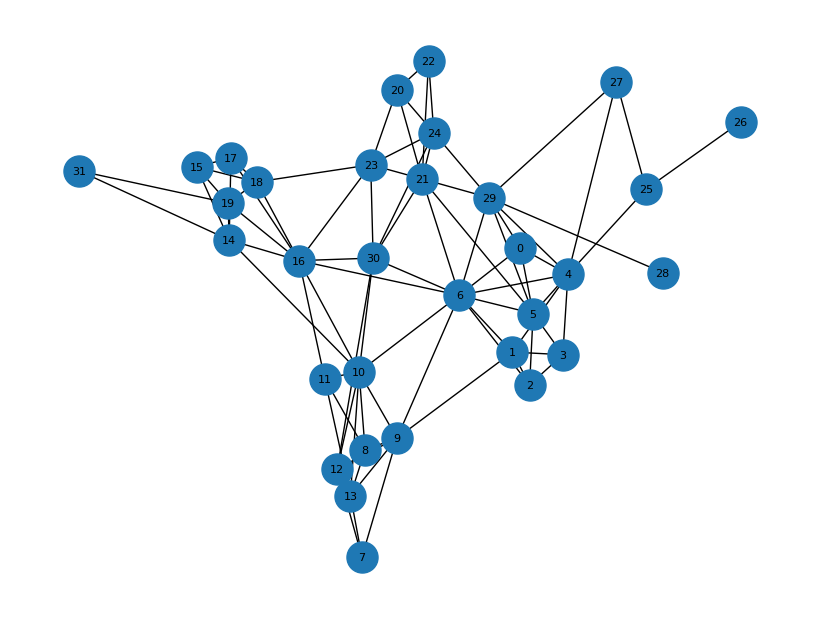

In [97]:
# Desenhar o grafo
plt.figure(figsize=(8,6))
nx.draw(G_comm, with_labels=True, node_size=500, font_size=8)
plt.show()

In [100]:
louvain_super_comms = louvain_communities(
    G_comm,
    weight="weight",
    seed=42,
    resolution=1.0
)

print("Supercomunidades:", len(louvain_super_comms))

Q_louvain = modularity(
    G_comm,
    louvain_super_comms,
    weight="weight"
)

print("Modularidade Supercomunidades:", Q_louvain)

Supercomunidades: 4
Modularidade Supercomunidades: 0.5873860233553945


In [ ]:
louvain_super_comm_membership = {}

for cid, community in enumerate(louvain_super_comms):

    for node in community:

        louvain_super_comm_membership[node] = cid

louvain_super_comm_df = pd.DataFrame({

    "node_id":
    list(louvain_super_comm_membership.keys()),

    "louvain":
    list(louvain_super_comm_membership.values())
})

louvain_super_comm_df.head()

,node_id,louvain
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


In [102]:
pd.Series(
    louvain_super_comm_membership
).value_counts().sort_values(
    ascending=False
).head(20)

0    12
1     7
2     7
3     6
Name: count, dtype: int64

In [106]:
print(louvain_membership)
print(louvain_super_comm_membership)

node_supergroup = {}

for node, community in louvain_membership.items():

    node_supergroup[node] = \
        louvain_super_comm_membership[community]
    
list(node_supergroup.items())[:10]

{'A_25': 0, 'C_620': 0, 'A_33': 0, 'C_55': 0, 'C_87': 0, 'A_16': 0, 'C_575': 0, 'A_44': 0, 'A_27': 0, 'C_924': 0, 'C_355': 0, 'A_6': 0, 'C_93': 0, 'C_637': 0, 'C_942': 0, 'A_41': 0, 'C_347': 0, 'A_47': 0, 'O_222': 0, 'Y_26': 0, 'C_350': 0, 'O_215': 0, 'A_24': 0, 'C_938': 0, 'C_625': 0, 'C_927': 0, 'C_91': 0, 'O_225': 0, 'A_20': 0, 'A_29': 0, 'O_218': 0, 'C_937': 0, 'C_90': 0, 'O_216': 0, 'A_19': 0, 'C_631': 0, 'C_925': 0, 'B_779': 0, 'C_568': 0, 'C_57': 0, 'A_21': 0, 'B_776': 0, 'C_358': 0, 'C_931': 0, 'C_565': 0, 'C_616': 0, 'A_40': 0, 'Y_23': 0, 'C_96': 0, 'A_12': 0, 'A_39': 0, 'C_99': 0, 'C_564': 0, 'Y_21': 0, 'C_619': 0, 'C_581': 0, 'Y_25': 0, 'A_26': 0, 'B_781': 0, 'C_939': 0, 'C_642': 0, 'C_636': 0, 'O_202': 0, 'C_640': 0, 'C_622': 0, 'O_217': 0, 'C_578': 0, 'C_566': 0, 'C_89': 0, 'C_58': 0, 'C_359': 0, 'A_46': 0, 'Y_28': 0, 'A_13': 0, 'A_38': 0, 'C_54': 0, 'C_627': 0, 'C_623': 0, 'A_11': 0, 'A_37': 0, 'Y_20': 0, 'C_100': 0, 'C_572': 0, 'C_357': 0, 'A_32': 0, 'C_936': 0, 'B_777':

[('A_25', 0),
 ('C_620', 0),
 ('A_33', 0),
 ('C_55', 0),
 ('C_87', 0),
 ('A_16', 0),
 ('C_575', 0),
 ('A_44', 0),
 ('A_27', 0),
 ('C_924', 0)]

In [107]:
super_df = pd.DataFrame({

    "node_id":
    list(node_supergroup.keys()),

    "supergroup":
    list(node_supergroup.values())
})

super_df.head()

,node_id,supergroup
0,A_25,0
1,C_620,0
2,A_33,0
3,C_55,0
4,C_87,0


In [109]:
chain_map = {

    node:G.nodes[node]["chain"]

    for node in G.nodes()
}

super_df["chain"] = \
    super_df["node_id"].map(chain_map)

In [111]:
def biological_class(chain):

    if chain in list("ABCDEFGHIJKL"):
        return "Hexon"

    elif chain == "M":
        return "Penton"

    else:
        return "Outros"
    
super_df["truth"] = \
    super_df["chain"].apply(
        biological_class
    )

In [112]:
pd.crosstab(
    super_df["truth"],
    super_df["supergroup"]
)

supergroup,0,1,2,3
truth,,,,
Hexon,3165,2722,2732,2306
Outros,496,165,212,291
Penton,455,0,0,0


In [113]:
from sklearn.metrics import (
    normalized_mutual_info_score,
    adjusted_rand_score
)

nmi_super = normalized_mutual_info_score(

    super_df["truth"],
    super_df["supergroup"]
)

ari_super = adjusted_rand_score(

    super_df["truth"],
    super_df["supergroup"]
)

print("NMI =", nmi_super)
print("ARI =", ari_super)

NMI = 0.05202734723506104
ARI = -0.009103408673822812


In [ ]:
chain_table = pd.crosstab(
    super_df["chain"],
    super_df["supergroup"]
)

chain_table

supergroup,0,1,2,3
chain,,,,
A,908,0,0,0
B,910,0,0,0
C,908,2,0,0
D,0,906,0,0
E,8,899,0,7
F,0,905,1,4
G,0,10,899,0
H,0,0,913,0
I,0,0,910,0


: 

In [93]:
############################################################
#  SALVAR ESTADO
############################################################

#import pickle
#from pathlib import Path

#CHECKPOINT = Path("checkpoints")
#CHECKPOINT.mkdir(exist_ok=True)

# Definição dos caminhos
#RESIDUOS_FILE = CHECKPOINT / "6B1T_residuos.csv"
#GRAPH_FILE = CHECKPOINT / "6B1T_graph.pkl"
#ADJ_FILE = CHECKPOINT / "6B1T_adjacency.npy"

# Salvar DataFrame
#res_df.to_csv(RESIDUOS_FILE, index=False)
#print(f"Arquivo de resíduos salvo em {RESIDUOS_FILE}")

# Salvar grafo
#with open(GRAPH_FILE, "wb") as f:
#    pickle.dump(G, f)
#print(f"Grafo salvo em {GRAPH_FILE}")

# Salvar matriz de adjacência
#np.save(ADJ_FILE, A)
#print(f"Matriz de adjacência salva em {ADJ_FILE}")


In [94]:
############################################################
#  RESTAURAR ESTADO
############################################################
#if RESIDUOS_FILE.exists():
#    res_df = pd.read_csv(RESIDUOS_FILE)
#    print("Resíduos carregados!")
#    print("Resíduos:", len(res_df))
#    print(res_df.head())
#else:
#    print("Arquivo de resíduos não encontrado.")
#
#if GRAPH_FILE.exists():
#    with open(GRAPH_FILE, "rb") as f:
#        G = pickle.load(f)
#    print("Grafo carregado!")
#    print("Nós:", G.number_of_nodes())
#    print("Arestas:", G.number_of_edges())
#else:
#    print("Arquivo de grafo não encontrado.")
#
#if ADJ_FILE.exists():
#    A = np.load(ADJ_FILE)
#    print("Matriz de adjacência carregada!")
#else:
#    print("Arquivo de matriz de adjacência não encontrado.")